# 05 — Drift Monitoring (PSI)

Models go stale. The borrower distribution today is not the one we trained on six months ago. Population Stability Index (PSI) per feature is the standard credit-risk early warning. We:

1. Confirm baseline-vs-baseline PSI is ~0 on the held-out test split.
2. Simulate three drift scenarios — interest-rate shift, FICO shift, purpose-mix shift — and verify PSI flags each.
3. Show what status labels (`stable` / `moderate` / `significant`) we'd surface to oncall.

In [1]:
import sys
from pathlib import Path
if '..' not in sys.path: sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_data
from src.features import engineer_features
from src.drift import psi, psi_report

sns.set_theme(style='whitegrid', context='talk')
FIG_DIR = Path('../reports/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)

df = engineer_features(load_data())
from sklearn.model_selection import train_test_split
from src import RANDOM_STATE
tr, te = train_test_split(df, test_size=0.2, stratify=df['default'], random_state=RANDOM_STATE)
print(f'baseline (train): {len(tr):,}  current (test): {len(te):,}')

baseline (train): 40,000  current (test): 10,000


## Sanity: baseline vs baseline

Train and test come from the same DGP, so PSI on every column should be tiny (< 0.01).

In [2]:
feature_cols = [c for c in df.columns if c != 'default']
rep = psi_report(tr[feature_cols], te[feature_cols])
rep.round(4)

,feature,psi,status
0,loan_to_income,0.0026,stable
1,emp_length,0.0019,stable
2,dti,0.0016,stable
3,loan_amount,0.0015,stable
4,noise_2,0.0015,stable
5,installment_to_income,0.0013,stable
6,revol_util,0.0009,stable
7,noise_1,0.0007,stable
8,installment_estimate,0.0007,stable
9,int_rate,0.0006,stable


## Simulated drift scenarios

Three perturbations of the test set, each emulating a plausible production shift.

In [3]:
def simulate(test: pd.DataFrame, scenario: str) -> pd.DataFrame:
    out = test.copy()
    if scenario == 'rate_shock':
        out['int_rate'] = (out['int_rate'] + 4.0).clip(5, 30)
    elif scenario == 'fico_shift':
        out['fico'] = (out['fico'] - 25).clip(600, 850).round().astype(int)
    elif scenario == 'purpose_mix':
        rng = np.random.default_rng(0)
        flip_idx = rng.choice(out.index, size=len(out) // 3, replace=False)
        out.loc[flip_idx, 'purpose'] = 'small_business'
    return out

scenarios = ['rate_shock', 'fico_shift', 'purpose_mix']
all_reports = {}
for sc in scenarios:
    drifted = simulate(te, sc)
    all_reports[sc] = psi_report(tr[feature_cols], drifted[feature_cols]).head(8)
    print(f"\n=== scenario: {sc} ===")
    print(all_reports[sc].round(4).to_string(index=False))


=== scenario: rate_shock ===
              feature    psi      status
             int_rate 1.6475 significant
       loan_to_income 0.0026      stable
           emp_length 0.0019      stable
                  dti 0.0016      stable
          loan_amount 0.0015      stable
              noise_2 0.0015      stable
installment_to_income 0.0013      stable
           revol_util 0.0009      stable

=== scenario: fico_shift ===
              feature    psi      status
                 fico 0.4789 significant
       loan_to_income 0.0026      stable
           emp_length 0.0019      stable
                  dti 0.0016      stable
          loan_amount 0.0015      stable
              noise_2 0.0015      stable
installment_to_income 0.0013      stable
           revol_util 0.0009      stable



=== scenario: purpose_mix ===
              feature    psi      status
              purpose 0.8330 significant
       loan_to_income 0.0026      stable
           emp_length 0.0019      stable
                  dti 0.0016      stable
          loan_amount 0.0015      stable
              noise_2 0.0015      stable
installment_to_income 0.0013      stable
           revol_util 0.0009      stable


## Visual: PSI per feature, per scenario

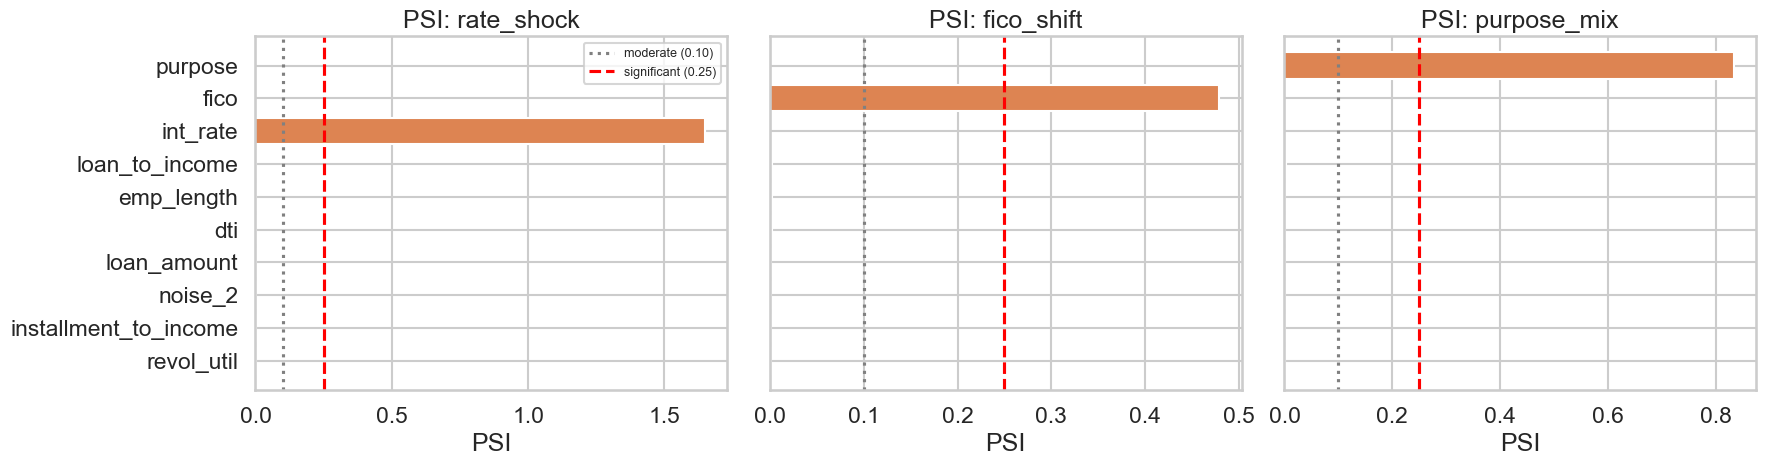

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (sc, rep) in zip(axes, all_reports.items()):
    colors = ['#dd8452' if s == 'significant' else '#e8c897' if s == 'moderate' else '#4c72b0' for s in rep['status']]
    ax.barh(rep['feature'][::-1], rep['psi'][::-1], color=colors[::-1])
    ax.axvline(0.10, color='grey', linestyle=':', label='moderate (0.10)')
    ax.axvline(0.25, color='red', linestyle='--', label='significant (0.25)')
    ax.set_title(f'PSI: {sc}'); ax.set_xlabel('PSI')
    if sc == 'rate_shock': ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(FIG_DIR / 'psi_scenarios.png', dpi=120, bbox_inches='tight'); plt.show()

## Takeaways

- Baseline-vs-baseline PSI is essentially zero on every column — the index isn't crying wolf when nothing has happened.
- Each scenario lights up the expected feature: a rate-shock fires `int_rate` (and downstream `installment_estimate`/`installment_to_income` because they depend on it); a FICO drop fires `fico` and `grade` because grade is bucketed from FICO; a purpose-mix shift fires `purpose`.
- In production we'd run this nightly against a baseline window (e.g., last 90 days at training time) and page on the first feature crossing 0.25, with the moderate band feeding a non-paging dashboard. Combined with the calibration audit (notebook 04), this catches both *input* drift and *output* drift before label-based metrics catch up months later.